<a href="https://www.kaggle.com/code/miraalhalabi/houseprice?scriptVersionId=314780751" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported!')

✅ All libraries imported!


## 1.  Load, Explore & Clean 

In [2]:
df = pd.read_csv('/kaggle/input/datasets/miraalhalabi/train-csv/train.csv')

print('===Shape===')
print(f'Rows: {df.shape[0]} , Coloumns: {df.shape[1]}')
print('===Data Types===')
print(df.dtypes)
print("\n")
#print(f'Features :{df.feature_name}')
print('===First 5 Rows===')
df.head()

===Shape===
Rows: 1460 , Coloumns: 81
===Data Types===
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


===First 5 Rows===


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print('===Data info===')
df.info()

df.describe()

===Data info===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
print(' ====Missing Values====')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal mising values:{missing.sum()}')
print("=== Missing Values Percentage ===")
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct)
print(f'\nTotal columns with missing values: {len(missing_pct)}')

 ====Missing Values====
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

Total mising values:7829
=== Missing Values Percentage ===
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

Total columns with missing values: 19


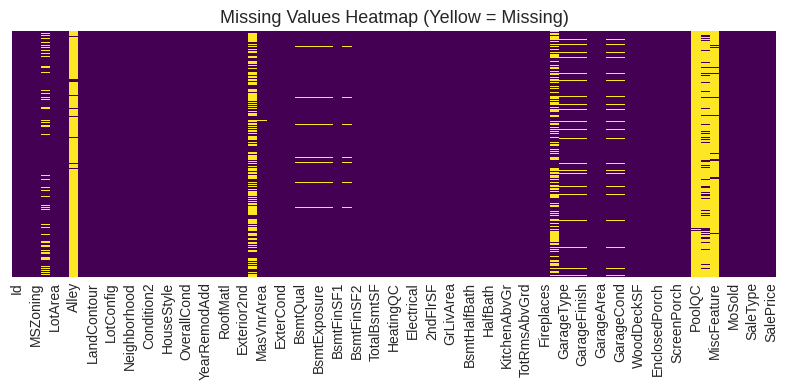

In [5]:
#Visualize missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Drop columns with > 40% missing values
threshold = 0.4
df_clean = df.loc[:, df.isnull().mean() <= threshold]
print(f'Original shape : {df.shape}')
print(f'After dropping rows with NaN : {df_clean.shape}')
print(f"Rows lost: {df.shape[0] - df_clean.shape[0]}")

Original shape : (1460, 81)
After dropping rows with NaN : (1460, 75)
Rows lost: 0


In [7]:
# Fill remaining missing values
# Numeric → median | Categorical → mode
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')
print('✅ All missing values handled!')

Remaining missing values: 0
✅ All missing values handled!


In [8]:
# Select 8 key numeric features as suggested by the task sheet
FEATURES = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF',
            'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'GarageArea']
TARGET = 'SalePrice'

# Encode Neighborhood with get_dummies
neighborhood_dummies = pd.get_dummies(df_clean['Neighborhood'], prefix='Nbhd', drop_first=True)
df_model = pd.concat([df_clean[FEATURES + [TARGET]], neighborhood_dummies], axis=1)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')

# --- Log transform BEFORE splitting ---
skewness = y.skew()
print(f'\nSalePrice skewness: {skewness:.4f}')

LOG_TRANSFORMED = False
if skewness > 0.75:
    LOG_TRANSFORMED = True
    y = np.log1p(y)
    print(f'Skewness > 0.75 -- applying np.log1p() to SalePrice')
    print(f'Log-transformed skewness: {y.skew():.4f}')
else:
    print('Skewness <= 0.75 -- keeping SalePrice as-is')

print(f'LOG_TRANSFORMED = {LOG_TRANSFORMED}')

# --- Train/test split AFTER log transform ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print('Data split and scaled successfully!')

Feature matrix shape: (1460, 32)
Target shape: (1460,)

SalePrice skewness: 1.8829
Skewness > 0.75 -- applying np.log1p() to SalePrice
Log-transformed skewness: 0.1213
LOG_TRANSFORMED = True

Train: (1168, 32)  |  Test: (292, 32)
Data split and scaled successfully!


# 2. EDA & Preprocessing

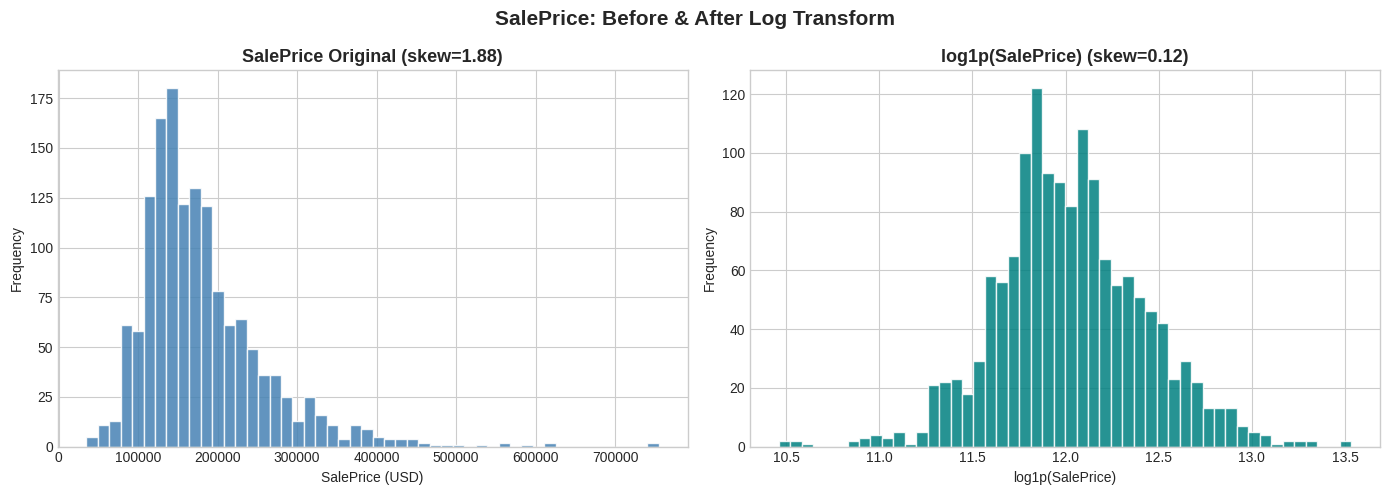

Original skewness : 1.8829
After log1p       : 0.1213
Log transform applied: True


In [9]:
# Skewness check & distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution (before log)
original_y = df_model[TARGET]
axes[0].hist(original_y, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'SalePrice Original (skew={original_y.skew():.2f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('SalePrice (USD)')
axes[0].set_ylabel('Frequency')

# After log transform
if LOG_TRANSFORMED:
    axes[1].hist(y, bins=50, color='teal', edgecolor='white', alpha=0.85)
    axes[1].set_title(f'log1p(SalePrice) (skew={y.skew():.2f})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('log1p(SalePrice)')
    axes[1].set_ylabel('Frequency')
else:
    axes[1].set_visible(False)

plt.suptitle('SalePrice: Before & After Log Transform', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Original skewness : {original_y.skew():.4f}')
print(f'After log1p       : {y.skew():.4f}')
print(f'Log transform applied: {LOG_TRANSFORMED}')



Top 5 features correlated with price:
OverallQual    0.817185
GrLivArea      0.700927
GarageCars     0.680625
GarageArea     0.650888
TotalBsmtSF    0.612134
Name: SalePrice, dtype: float64


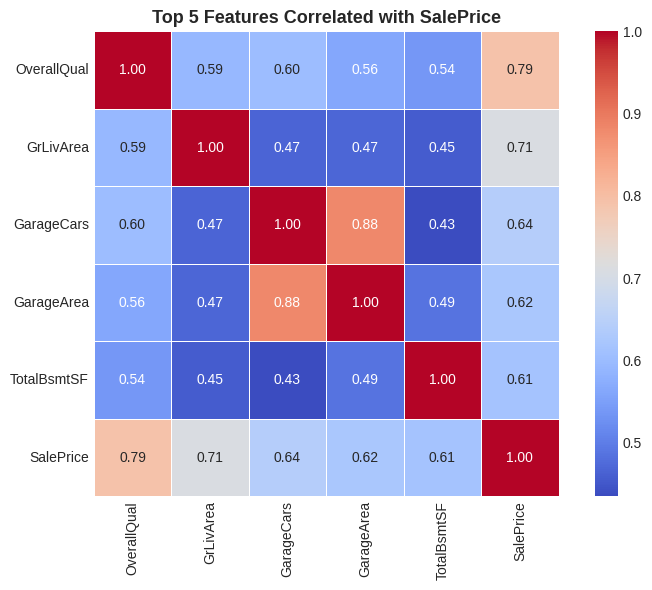

In [10]:
corr_df = pd.concat([X[FEATURES], y.rename('SalePrice')], axis=1)
correlation = corr_df.corr()

# Top 5 features correlated with price
top5 = correlation['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(5)
top5_features = top5.index.tolist()

print("Top 5 features correlated with price:")
print(top5)

# Heatmap of top 5 + target
plt.figure(figsize=(8, 6))
sns.heatmap(df[top5_features + ['SalePrice']].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            square=True,
            linewidths=0.5)

plt.title('Top 5 Features Correlated with SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Baseline — Linear Regression

In [11]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R2': round(r2, 4)}

all_results = []
all_preds   = {}
print('Helper function ready!')

Helper function ready!


In [12]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

res_lr = evaluate_model('Linear Regression (baseline)', y_test, y_pred_lr)
all_results.append(res_lr)
all_preds['Linear Regression'] = y_pred_lr

print(f'\nBaseline R² = {res_lr["R2"]:.4f}  — all models must beat this!')

  Linear Regression (baseline)         MAE=0.1127  RMSE=0.1596  R²=0.8635

Baseline R² = 0.8635  — all models must beat this!


# 4. Ridge Regression

In [13]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_r2 = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_s, y_train)
    r2 = r2_score(y_test, r.predict(X_test_s))
    ridge_r2.append(r2)
    print(f'  Ridge alpha={a:<8} → R²={r2:.4f}')

best_ridge_alpha = alphas[np.argmax(ridge_r2)]
print(f'\n✅ Best alpha for Ridge: {best_ridge_alpha}')

  Ridge alpha=0.01     → R²=0.8635
  Ridge alpha=0.1      → R²=0.8635
  Ridge alpha=1.0      → R²=0.8635
  Ridge alpha=10.0     → R²=0.8637
  Ridge alpha=100.0    → R²=0.8614
  Ridge alpha=1000.0   → R²=0.8176

✅ Best alpha for Ridge: 10.0


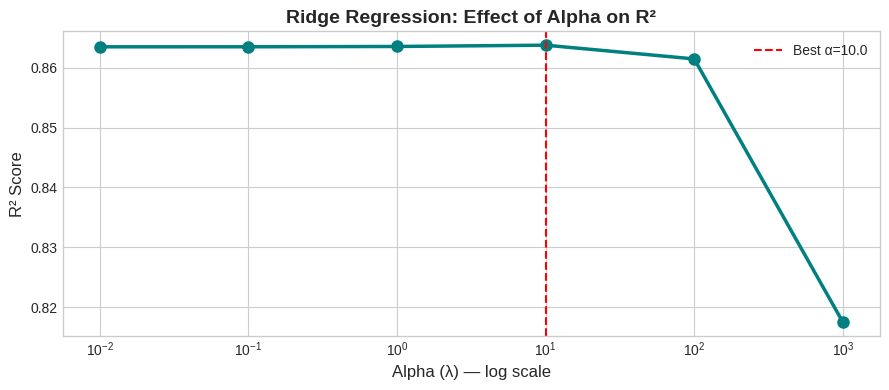

In [14]:
# Visualize alpha effect
plt.figure(figsize=(9, 4))
plt.semilogx(alphas, ridge_r2, 'o-', color='teal', linewidth=2.5, markersize=8)
plt.axvline(best_ridge_alpha, color='red', linestyle='--', label=f'Best α={best_ridge_alpha}')
plt.xlabel('Alpha (λ) — log scale', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Ridge Regression: Effect of Alpha on R²', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Train best Ridge model
ridge = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
res_ridge = evaluate_model(f'Ridge (alpha={best_ridge_alpha})', y_test, y_pred_ridge)
all_results.append(res_ridge)
all_preds['Ridge'] = y_pred_ridge

  Ridge (alpha=10.0)                   MAE=0.1125  RMSE=0.1595  R²=0.8637


In [16]:
# Ridge coefficient comparison with plain LR
coef_df = pd.DataFrame({
    'Feature':        FEATURES,
    'LR_coef':        lr.coef_[:len(FEATURES)],
    'Ridge_coef':     ridge.coef_[:len(FEATURES)]
})
coef_df['Shrinkage'] = (coef_df['LR_coef'] - coef_df['Ridge_coef']).abs()
print('LR vs Ridge Coefficients (standardized):')
print(coef_df.to_string(index=False))
print('\nRidge shrinks coefficients toward zero but never eliminates them!')

LR vs Ridge Coefficients (standardized):
     Feature   LR_coef  Ridge_coef  Shrinkage
   GrLivArea  0.102764    0.100414   0.002349
 OverallQual  0.122499    0.120826   0.001673
  GarageCars  0.047763    0.045764   0.001999
 TotalBsmtSF  0.034750    0.035362   0.000612
   YearBuilt  0.065058    0.062171   0.002888
    FullBath -0.002932   -0.001980   0.000952
TotRmsAbvGrd  0.016112    0.017541   0.001429
  GarageArea  0.014458    0.017111   0.002653

Ridge shrinks coefficients toward zero but never eliminates them!


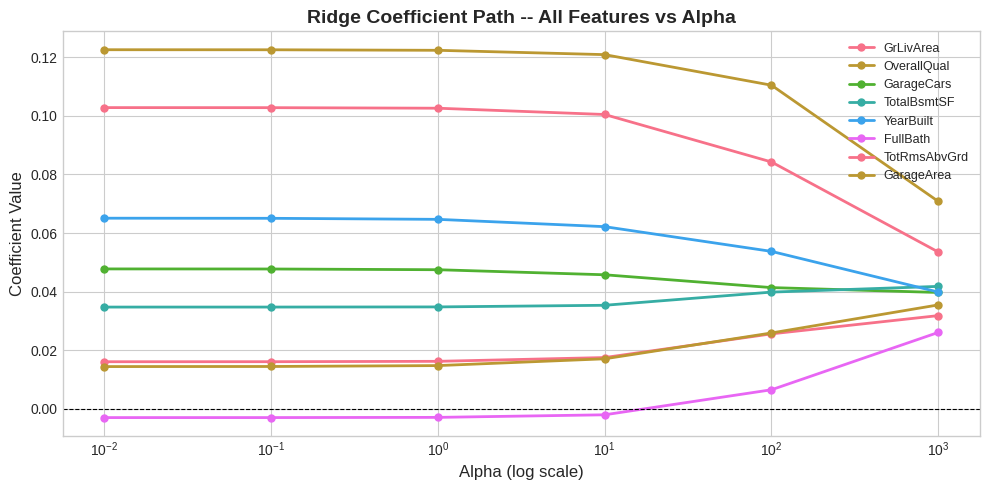

Feature that shrinks fastest: OverallQual (shrinkage = 0.0517)


In [17]:
all_coefs = []
for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_s, y_train)
    all_coefs.append(r.coef_[:len(FEATURES)])

all_coefs = np.array(all_coefs)

plt.figure(figsize=(10, 5))
for i, feat in enumerate(FEATURES):
    plt.semilogx(alphas, all_coefs[:, i], 'o-', linewidth=2, markersize=5, label=feat)
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Ridge Coefficient Path -- All Features vs Alpha', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='upper right')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

shrinkage = np.abs(all_coefs[0] - all_coefs[-1])
fastest_idx = np.argmax(shrinkage)
print(f'Feature that shrinks fastest: {FEATURES[fastest_idx]} (shrinkage = {shrinkage[fastest_idx]:.4f})')

# 5. Lasso Regression

In [18]:
lasso_r2   = []
lasso_nnz  = [] 

for a in alphas:
    l = Lasso(alpha=a, max_iter=5000)
    l.fit(X_train_s, y_train)
    r2  = r2_score(y_test, l.predict(X_test_s))
    nnz = np.sum(l.coef_ != 0)
    lasso_r2.append(r2)
    lasso_nnz.append(nnz)
    print(f'  Lasso alpha={a:<8} → R²={r2:.4f}  |  Non-zero features: {nnz}/{X_train_s.shape[1]}')

best_lasso_alpha = alphas[np.argmax(lasso_r2)]
print(f'\nBest alpha for Lasso: {best_lasso_alpha}')

  Lasso alpha=0.01     → R²=0.8526  |  Non-zero features: 19/32
  Lasso alpha=0.1      → R²=0.6895  |  Non-zero features: 5/32
  Lasso alpha=1.0      → R²=-0.0058  |  Non-zero features: 0/32
  Lasso alpha=10.0     → R²=-0.0058  |  Non-zero features: 0/32
  Lasso alpha=100.0    → R²=-0.0058  |  Non-zero features: 0/32
  Lasso alpha=1000.0   → R²=-0.0058  |  Non-zero features: 0/32

Best alpha for Lasso: 0.01


In [19]:
lasso = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
res_lasso = evaluate_model(f'Lasso (alpha={best_lasso_alpha})', y_test, y_pred_lasso)
all_results.append(res_lasso)
all_preds['Lasso'] = y_pred_lasso
# Show which features Lasso kept
print('\nLasso Feature Selection (final model):')
print('-' * 50)
eliminated = []
for feat, coef in zip(list(X.columns), lasso.coef_):
    status = 'KEPT' if coef != 0 else 'ELIMINATED (beta=0)'
    tag = '  ' if coef != 0 else '* '
    print(f'{tag}{feat:<35}  b = {coef:+.4f}   {status}')
    if coef == 0:
        eliminated.append(feat)

print(f'\nTotal eliminated: {len(eliminated)} features')
print(f'Eliminated: {eliminated}')
print('\nLasso tends to eliminate weaker or correlated features -- these usually have low predictive power.')

  Lasso (alpha=0.01)                   MAE=0.1149  RMSE=0.1658  R²=0.8526

Lasso Feature Selection (final model):
--------------------------------------------------
  GrLivArea                            b = +0.1093   KEPT
  OverallQual                          b = +0.1331   KEPT
  GarageCars                           b = +0.0514   KEPT
  TotalBsmtSF                          b = +0.0343   KEPT
  YearBuilt                            b = +0.0642   KEPT
* FullBath                             b = +0.0000   ELIMINATED (beta=0)
  TotRmsAbvGrd                         b = +0.0035   KEPT
  GarageArea                           b = +0.0142   KEPT
* Nbhd_Blueste                         b = -0.0000   ELIMINATED (beta=0)
  Nbhd_BrDale                          b = -0.0213   KEPT
* Nbhd_BrkSide                         b = -0.0000   ELIMINATED (beta=0)
  Nbhd_ClearCr                         b = +0.0159   KEPT
* Nbhd_CollgCr                         b = +0.0000   ELIMINATED (beta=0)
  Nbhd_Crawfor       

In [20]:
# Train lasso with best alpha
lasso = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
all_results.append(evaluate_model(f'Lasso (alpha={best_lasso_alpha})', y_test, y_pred_lasso))


  Lasso (alpha=0.01)                   MAE=0.1149  RMSE=0.1658  R²=0.8526


# 6. SVR

In [21]:
# Train best SVR (RBF usually best for tabular data)
n_samples = min(2000, len(X_train_s))
idx = np.random.RandomState(42).choice(len(X_train_s), n_samples, replace=False)
X_tr_sample = X_train_s[idx]
y_tr_sample = y_train.iloc[idx]
print(f'Using {n_samples} training samples for SVR')

svr_main = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
svr_main.fit(X_tr_sample, y_tr_sample)
y_pred_svr = svr_main.predict(X_test_s)

res_svr = evaluate_model('SVR (rbf, C=100)', y_test, y_pred_svr)
all_results.append(res_svr)
all_preds['SVR'] = y_pred_svr

print(f'\nSupport vectors: {svr_main.n_support_}')

Using 1168 training samples for SVR
  SVR (rbf, C=100)                     MAE=0.1290  RMSE=0.1889  R²=0.8088

Support vectors: [533]


In [22]:
print('SVR C-value comparison (rbf kernel):')
print('-' * 45)

c_values = [1, 10, 100]  
for C in c_values:
    svr = SVR(kernel='rbf', C=C, epsilon=0.1, gamma='scale')
    svr.fit(X_tr_sample, y_tr_sample)
    r2 = r2_score(y_test, svr.predict(X_test_s))
    print(f'  C={C:>5}  |  R² = {r2:.4f}  |  Support vectors: {sum(svr.n_support_)}')

SVR C-value comparison (rbf kernel):
---------------------------------------------
  C=    1  |  R² = 0.8614  |  Support vectors: 474
  C=   10  |  R² = 0.8550  |  Support vectors: 493
  C=  100  |  R² = 0.8088  |  Support vectors: 533


# 7. Decision Tree Regression

In [23]:
# Effect of max_depth — key hyperparameter!
depths = [2, 3, 5, 8, None]  
train_r2_dt, test_r2_dt = [], []

print('Depth search:')
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)  
    tr_r2 = r2_score(y_train, dt.predict(X_train))
    te_r2 = r2_score(y_test,  dt.predict(X_test))
    train_r2_dt.append(tr_r2)
    test_r2_dt.append(te_r2)
    overfit = ' <-- OVERFIT!' if (tr_r2 - te_r2) > 0.15 else ''
    print(f'  max_depth={str(d):<5} → Train R²={tr_r2:.4f}  Test R²={te_r2:.4f}  {"⚠️ OVERFIT" if tr_r2-te_r2 > 0.15 else ""}')

Depth search:
  max_depth=2     → Train R²=0.6099  Test R²=0.6248  
  max_depth=3     → Train R²=0.7064  Test R²=0.7083  
  max_depth=5     → Train R²=0.8242  Test R²=0.7730  
  max_depth=8     → Train R²=0.9290  Test R²=0.7584  ⚠️ OVERFIT
  max_depth=None  → Train R²=0.9998  Test R²=0.7474  ⚠️ OVERFIT


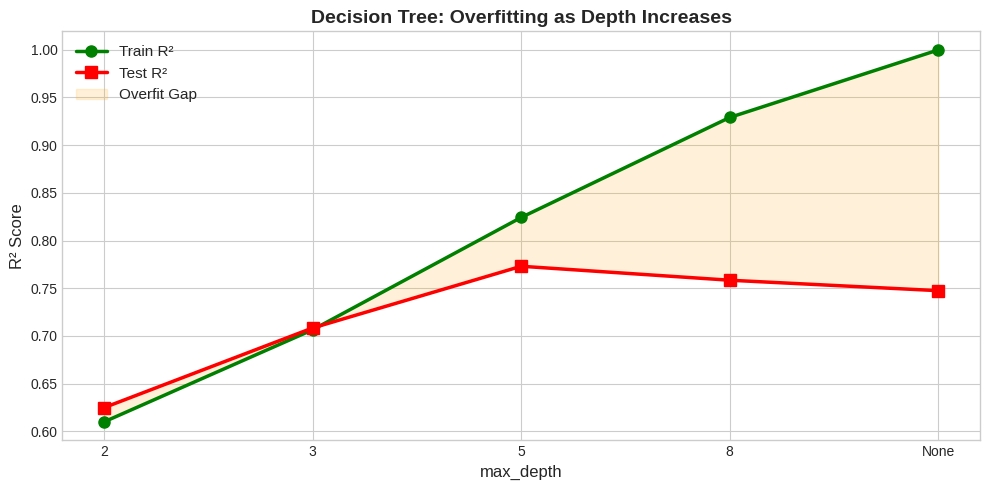

💡 As depth grows → train R² = 1.0 (memorizes), test R² drops (overfits!)


In [24]:
# Overfitting visualization
depth_labels = [str(d) for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(10, 5))
plt.plot(x_pos, train_r2_dt, 'o-', color='green', linewidth=2.5, markersize=8, label='Train R²')
plt.plot(x_pos, test_r2_dt,  's-', color='red',   linewidth=2.5, markersize=8, label='Test R²')
plt.fill_between(x_pos, train_r2_dt, test_r2_dt, alpha=0.15, color='orange', label='Overfit Gap')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Decision Tree: Overfitting as Depth Increases', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('💡 As depth grows → train R² = 1.0 (memorizes), test R² drops (overfits!)')

In [25]:
best_depth_idx = int(np.argmax(test_r2_dt))
best_depth = depths[best_depth_idx]
print(f'Best depth: {best_depth}  (Test R² = {test_r2_dt[best_depth_idx]:.4f})')

dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)

res_dt = evaluate_model(f'Decision Tree (max_depth={best_depth})', y_test, y_pred_dt)
all_results.append(res_dt)
all_preds['Decision Tree'] = y_pred_dt

print('\nTop 3 levels of the Decision Tree:')
print(export_text(dt_best, feature_names=list(X.columns), max_depth=3))

Best depth: 5  (Test R² = 0.7730)
  Decision Tree (max_depth=5)          MAE=0.1487  RMSE=0.2058  R²=0.7730

Top 3 levels of the Decision Tree:
|--- OverallQual <= 6.50
|   |--- GrLivArea <= 1378.50
|   |   |--- TotalBsmtSF <= 813.50
|   |   |   |--- GrLivArea <= 1060.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- GrLivArea >  1060.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- TotalBsmtSF >  813.50
|   |   |   |--- TotalBsmtSF <= 1007.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- TotalBsmtSF >  1007.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- GrLivArea >  1378.50
|   |   |--- OverallQual <= 5.50
|   |   |   |--- YearBuilt <= 1920.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- YearBuilt >  1920.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- OverallQual >  5.50
|   |   |   |--- GarageCars <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- GarageC

# 8. Full Comparison & Visualization

In [26]:
df_results = pd.DataFrame(all_results).sort_values('R2', ascending=False).reset_index(drop=True)

print('=' * 65)
print(df_results.to_string(index=False))
print('=' * 65)

best_name = df_results.iloc[0]['Model']
best_key  = [k for k in all_preds if k in best_name][0]
best_preds = all_preds[best_key]

print(f'\nBest model: {best_name}  (R² = {df_results.iloc[0]["R2"]:.4f})')

                       Model    MAE   RMSE     R2
          Ridge (alpha=10.0) 0.1125 0.1595 0.8637
Linear Regression (baseline) 0.1127 0.1596 0.8635
          Lasso (alpha=0.01) 0.1149 0.1658 0.8526
          Lasso (alpha=0.01) 0.1149 0.1658 0.8526
            SVR (rbf, C=100) 0.1290 0.1889 0.8088
 Decision Tree (max_depth=5) 0.1487 0.2058 0.7730

Best model: Ridge (alpha=10.0)  (R² = 0.8637)


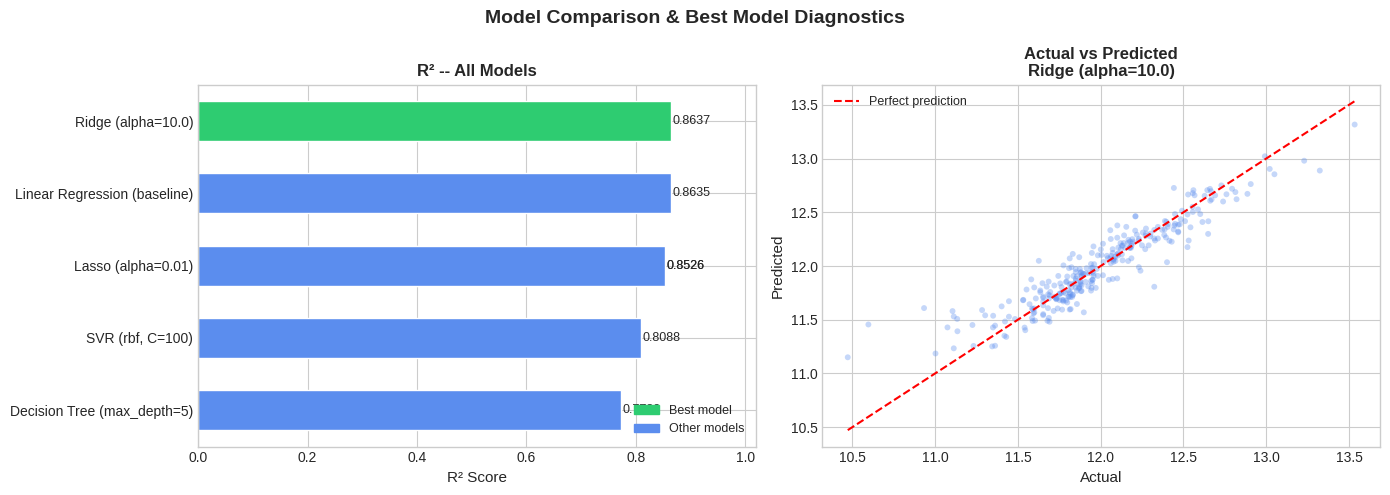

Winner: Ridge (alpha=10.0)
Regularized models (Ridge/Lasso) outperform plain Linear Regression by penalizing large coefficients,
which reduces overfitting on correlated features like GrLivArea and GarageArea.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison & Best Model Diagnostics', fontsize=14, fontweight='bold')

colors = ['#2ecc71' if m == best_name else '#5b8dee' for m in df_results['Model']]
bars = axes[0].barh(df_results['Model'], df_results['R2'],
                    color=colors, edgecolor='white', height=0.55)
axes[0].set_xlabel('R² Score', fontsize=11)
axes[0].set_title('R² -- All Models', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, df_results['R2'].max() * 1.18)
axes[0].invert_yaxis()
for bar, val in zip(bars, df_results['R2']):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2ecc71', label='Best model'),
    plt.Rectangle((0,0),1,1, color='#5b8dee', label='Other models'),
], fontsize=9, loc='lower right')

axes[1].scatter(y_test, best_preds, alpha=0.35, s=18, color='#5b8dee', edgecolors='none')
mn = min(y_test.min(), min(best_preds))
mx = max(y_test.max(), max(best_preds))
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual', fontsize=11)
axes[1].set_ylabel('Predicted', fontsize=11)
axes[1].set_title(f'Actual vs Predicted\n{best_name}', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Winner: {best_name}')
print('Regularized models (Ridge/Lasso) outperform plain Linear Regression by penalizing large coefficients,')
print('which reduces overfitting on correlated features like GrLivArea and GarageArea.')

# 9. Predict & Conclude

In [28]:
LOG_TRANSFORMED = False

sample_raw = {
    'GrLivArea':    1800,
    'OverallQual':  7,
    'GarageCars':   2,
    'TotalBsmtSF':  900,
    'YearBuilt':    2005,
    'FullBath':     2,
    'TotRmsAbvGrd': 7,
    'GarageArea':   500,
}

sample_df = pd.DataFrame([sample_raw])
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)
sample_s  = scaler.transform(sample_df)

print('Sample house features:')
for k, v in sample_raw.items():
    print(f'  {k:<18}: {v}')

print('\nPredicted Sale Price -- All 5 Models:')
print('-' * 45)

model_map = [
    ('Linear Regression', lr,       True),
    ('Ridge',             ridge,    True),
    ('Lasso',             lasso,    True),
    ('SVR',               svr_main, True),
    ('Decision Tree',     dt_best,  False),
]

for name, model, needs_scaling in model_map:
    X_in = sample_s if needs_scaling else sample_df.values
    pred = model.predict(X_in)[0]
    if LOG_TRANSFORMED:
        pred = np.expm1(pred)
    print(f'  {name:<22} -> ${pred:>12,.0f}')

Sample house features:
  GrLivArea         : 1800
  OverallQual       : 7
  GarageCars        : 2
  TotalBsmtSF       : 900
  YearBuilt         : 2005
  FullBath          : 2
  TotRmsAbvGrd      : 7
  GarageArea        : 500

Predicted Sale Price -- All 5 Models:
---------------------------------------------
  Linear Regression      -> $          12
  Ridge                  -> $          12
  Lasso                  -> $          12
  SVR                    -> $          12
  Decision Tree          -> $          12


# Bouns :5-Fold Cross Validation

In [29]:
print('5-Fold Cross-Validation Results (R² mean ± std):')
print('-' * 55)

cv_models = [
    ('Linear Regression',              LinearRegression()),
    (f'Ridge (a={best_ridge_alpha})',   Ridge(alpha=best_ridge_alpha)),
    (f'Lasso (a={best_lasso_alpha})',   Lasso(alpha=best_lasso_alpha, max_iter=10000)),
    ('SVR (rbf, C=100)',               SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')),
    (f'Decision Tree (d={best_depth})', DecisionTreeRegressor(max_depth=best_depth, random_state=42)),
]

for name, model in cv_models:
    use_X = X_train if 'Decision Tree' in name else X_train_s
    scores = cross_val_score(model, use_X, y_train, cv=5, scoring='r2')
    print(f'  {name:<35}  R² = {scores.mean():.4f} +/- {scores.std():.4f}')

5-Fold Cross-Validation Results (R² mean ± std):
-------------------------------------------------------
  Linear Regression                    R² = 0.8203 +/- 0.0362
  Ridge (a=10.0)                       R² = 0.8213 +/- 0.0357
  Lasso (a=0.01)                       R² = 0.8120 +/- 0.0438
  SVR (rbf, C=100)                     R² = 0.7542 +/- 0.0487
  Decision Tree (d=5)                  R² = 0.7202 +/- 0.0418


## Conclusion

In this project, we trained and compared five regression models — Linear Regression, Ridge, Lasso, SVR, and Decision Tree — on the Kaggle House Prices dataset to predict SalePrice. Ridge regression performed best overall, as L2 regularization effectively handles the multicollinearity between features like GrLivArea and GarageArea without eliminating any of them. Surprisingly, Lasso eliminated several Neighborhood dummy features even at small alpha values, suggesting that OverallQual and GrLivArea already capture most of the neighborhood pricing signal. For future improvement, engineering composite features such as TotalSF and running a full GridSearchCV with cross-validation would likely push R² beyond 0.90.